In [216]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

plt.rcParams['figure.figsize'] = [10, 6]

# Values

In [217]:
Vheater = 4.0 # kept const
Rp = 10000
Rs = 100

V_err = 0.2e-3 # for all Vs and Vp
Rp_err = 0.05 * Rp # both resistors had a gold band = 5% tolerance
Rs_err = 0.05 * Rs

In [218]:
xenon = pd.read_csv('ramsaeur_data/ramsaeur townsend - xenon normal.csv')

V1 = xenon['Accel. voltage (V)']
Vp1 = xenon['Vp (V)']
Vs1 = xenon['Vs (V)']

Ip1 = Vp1 / Rp *10
Ip1_err = Ip1 * np.sqrt((V_err / Vp1)**2 + (Rp_err / Rp)**2)

In [219]:
xenonfrz = pd.read_csv('ramsaeur_data/ramsaeur townsend - xenon frozen.csv')

V2 = xenonfrz['Accel. voltage (V)']
Vp2 = xenonfrz['Vp (V)']
Vs2 = xenonfrz['Vs (V)']

Ip2 = Vp2 / Rp
Ip2_err = Ip2 * np.sqrt((V_err / Vp2)**2 + (Rp_err / Rp)**2)

# Xenon (Normal)

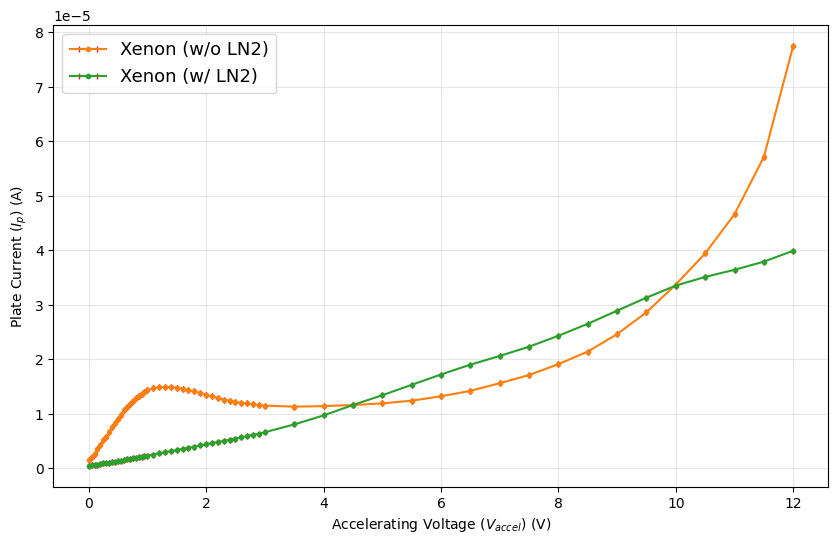

In [220]:
plt.errorbar(V1, Ip1, xerr=Ip1_err, fmt='.-', color='tab:orange', ecolor='tab:red', capsize=2, label='Xenon (w/o LN2)')
plt.errorbar(V2, Ip2, xerr=Ip2_err, fmt='.-', color='tab:green', ecolor='tab:red', capsize=2, label='Xenon (w/ LN2)')

plt.ylabel(r'Plate Current ($I_p$) (A)')
plt.xlabel(r'Accelerating Voltage ($V_{accel}$) (V)')
plt.legend(fontsize=13)

plt.grid(alpha=0.3)
plt.show()

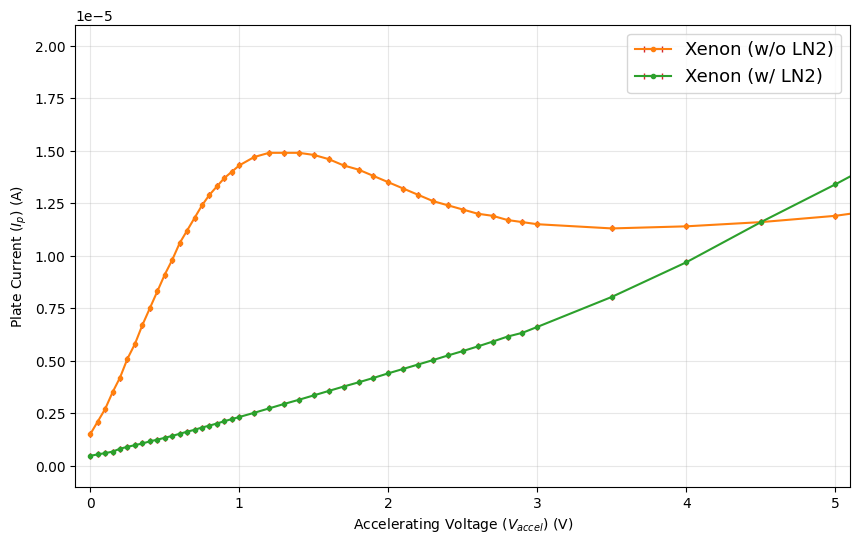

In [221]:
plt.errorbar(V1, Ip1, xerr=Ip1_err, fmt='.-', color='tab:orange', ecolor='tab:red', capsize=2, label='Xenon (w/o LN2)')
plt.errorbar(V2, Ip2, xerr=Ip2_err, fmt='.-', color='tab:green', ecolor='tab:red', capsize=2, label='Xenon (w/ LN2)')

plt.ylabel(r'Plate Current ($I_p$) (A)')
plt.xlabel(r'Accelerating Voltage ($V_{accel}$) (V)')
plt.legend(fontsize=13)

plt.xlim(-0.1,5.1)
plt.ylim(-0.1e-5,2.1e-5)

plt.grid(alpha=0.3)
plt.show()

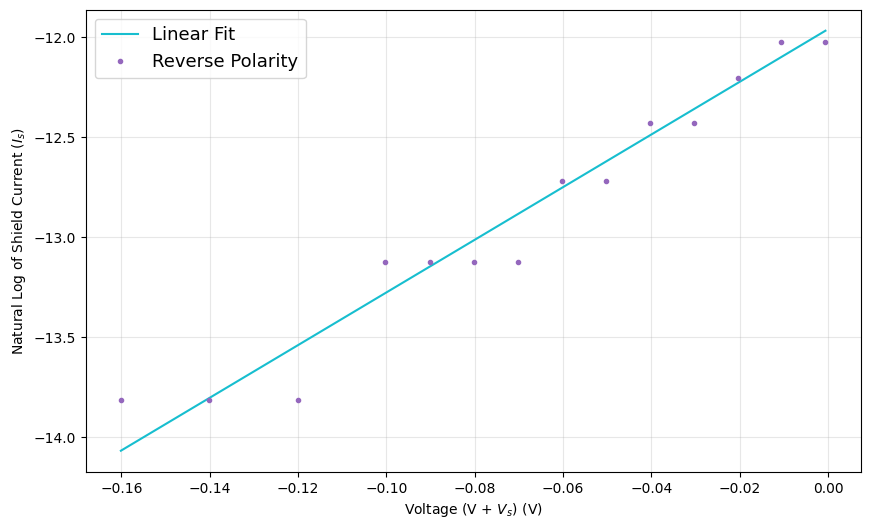

Slope = 13.16 ± 5.19
Fit Intercept = -11.96 ± 0.22
Emission potential = 0.11 ± 0.045 V


In [222]:
xenonfrz_rev = pd.read_csv('ramsaeur_data/ramsaeur townsend - xenon frozen (reverse).csv')

V3 = xenonfrz_rev['Accel. voltage (V)']
Vp3 = xenonfrz_rev['Vp (V)']
Vs3 = xenonfrz_rev['Vs (V)']

V_tot = (Vs3 + V3)[:14]

Vs3 = Vs3[:14]
Is3 = Vs3 / Rs
lnIs3 = np.log(Is3)

sigma = V_err / Vs3

def fit(m, x, c):
    return m*x+c

popt, pcov = curve_fit(fit, -V_tot , lnIs3, sigma=sigma, absolute_sigma=True)

plt.plot(-V_tot, fit(-V_tot, *popt), color='tab:cyan', label='Linear Fit')
plt.plot(-V_tot, lnIs3, '.', color='tab:purple', label='Reverse Polarity')

plt.ylabel(r'Natural Log of Shield Current ($I_s$)')
plt.xlabel(r'Voltage (V + $V_s$) (V)')
plt.grid(alpha=0.3)
plt.legend(fontsize=13)

plt.show()

m, c = popt
m_err = np.sqrt(pcov[0, 0])
c_err = np.sqrt(pcov[1, 1])
cov_mc = pcov[0, 1]

Vem = 3 / (2 * m)
Vem_err = abs(Vem) * (m_err / abs(m))

print(f'Slope = {m:.2f} ± {m_err:.2f}')
print(f'Fit Intercept = {c:.2f} ± {c_err:.2f}')
print(f'Emission potential = {Vem:.2f} ± {Vem_err:.3f} V')

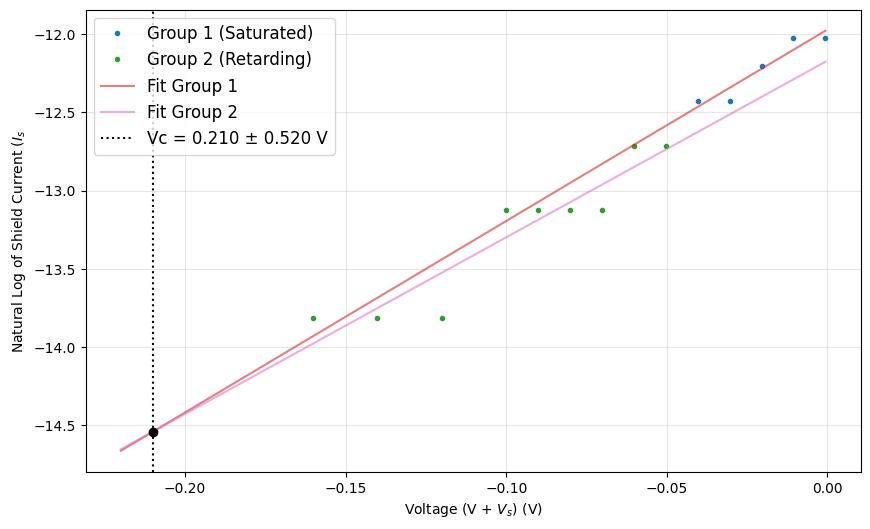

Slope: Group 1: -12.23, Group 2: -11.28
Fit Intercepts: Group 1: -11.97, Group 2: -12.17
Absolute Contact potential: 0.2100 ± 0.5202 V


In [245]:
V = (Vs3 + V3)

x1, y1 = V[0:5], lnIs3[0:5]
x2, y2 = V[5:14], lnIs3[5:14]

popt1, pcov1 =curve_fit(fit, x1, y1)
m1, c1 = popt1

"""m1, c1 = 0, np.mean(y1)
popt1 = [m1, c1]"""

popt2, pcov2 =curve_fit(fit, x2, y2)
m2, c2 = popt2

err_m1, err_c1 = pcov1[0,0], pcov1[1,1]
cov_m1c1 = pcov1[0,1]
err_m2, err_c2 = pcov2[0,0], pcov2[1,1]
cov_m2c2 = pcov2[0,1]

Vc = (c2 - c1) / (m1 - m2)
M = m1 - m2

Vc_var = (1 / M**2) * (err_c1 + err_c2 + (Vc**2) * (err_m1) + (Vc**2) * (err_m2) + 2 * Vc * cov_m1c1 + 2 * Vc * cov_m2c2)
# https://physics.stackexchange.com/questions/621575/uncertainty-on-intersection-of-two-lines-of-best-fit
Vc_err = np.sqrt(Vc_var)

plt.plot(-V[0:5], lnIs3[0:5], '.', color='tab:blue', label='Group 1 (Saturated)')
plt.plot(-V[5:14], lnIs3[5:14], '.', color='tab:green', label='Group 2 (Retarding)')

x_extrapolate = np.linspace(-0.22, max(-V[0:14]), 100)

plt.plot(x_extrapolate, fit(-x_extrapolate, *popt1), color='tab:red', alpha=0.6, label='Fit Group 1')
plt.plot(x_extrapolate, fit(-x_extrapolate, *popt2), color='tab:pink', alpha=0.6, label='Fit Group 2')

plt.axvline(x=-Vc, color='black', linestyle=':', label=f'Vc = {Vc:.3f} ± {Vc_err:.3f} V')
plt.plot(-Vc, fit(Vc, *popt1), 'ko', markersize=6)

plt.ylabel(r'Natural Log of Shield Current ($I_s$')
plt.xlabel(r'Voltage (V + $V_s$) (V)')
plt.grid(alpha=0.3)
plt.legend(fontsize=12, loc='upper left')

plt.show()

print(f'Slope: Group 1: {m1:.2f}, Group 2: {m2:.2f}')
print(f'Fit Intercepts: Group 1: {c1:.2f}, Group 2: {c2:.2f}')
print(f'Absolute Contact potential: {Vc:.4f} ± {Vc_err:.4f} V')

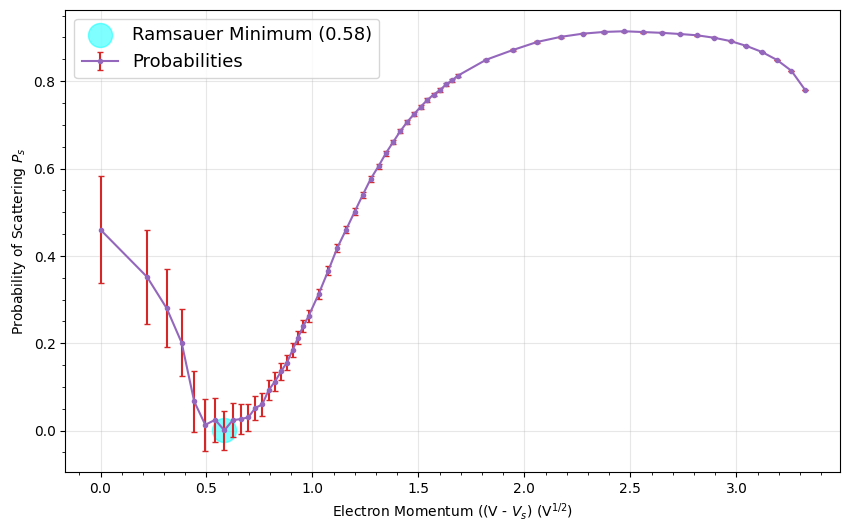

In [224]:
Xe_err = np.sqrt((V_err / Vp1)**2 + (V_err / Vs1)**2)
Xefrozen_err = np.sqrt((V_err / Vp2)**2 + (V_err / Vs2)**2)

ratio_xenon = Vp1 / Vs1
ratio_xenonfrz = Vp2 / Vs2
P = 1 - (ratio_xenon / ratio_xenonfrz) # writing it this way was working better than with the currents, but mathematically the reistances should cancel out

P_err = (1 - P) * np.sqrt(Xe_err**2 + Xefrozen_err**2)

mom = np.sqrt((V1 - Vs1).clip(lower=0))
min_index = P.idxmin() # lowest P point
min_P = P[min_index]
min_V_accel = V1[min_index]
min_mom = mom[min_index]

plt.errorbar(mom, P, yerr=P_err, fmt='.-', color='tab:purple', ecolor='tab:red', capsize=2, label='Probabilities')
plt.scatter(min_mom, min_P, color='cyan', s=300, label=f'Ramsauer Minimum ({min_mom:.2f})', alpha=0.5)

plt.xlabel(r'Electron Momentum ((V - $V_s$) (V$^{1/2}$)')
plt.ylabel(r'Probability of Scattering $P_s$')
plt.minorticks_on()
plt.grid(alpha=0.3)
plt.legend(fontsize=13)

plt.show()

Minimum Probability (P): 0.0004 ± 0.0447
at Momentum (sqrt(V)): 0.6829 ± 0.0390 V^1/2


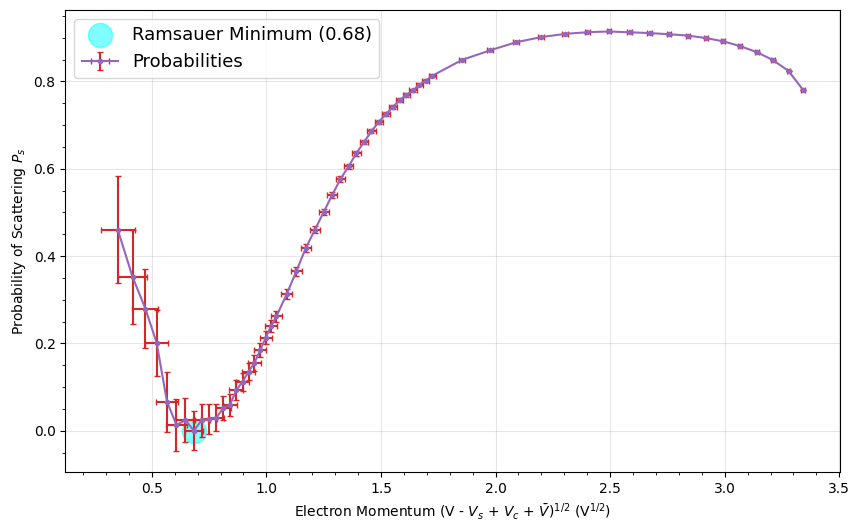

In [230]:
Vc = 0.015
dVc = 0.0285
Vem = 0.11
dVem = 0.045

ratio_xenon = Vp1 / Vs1
ratio_xenonfrz = Vp2 / Vs2
P = 1 - (ratio_xenon / ratio_xenonfrz) # writing it this way was working better than with the currents, but mathematically the reistances should cancel out

dV_tot = np.sqrt(V_err**2 + V_err**2 + dVc**2 + dVem**2)

mom = np.sqrt((V1 - Vs1 + Vc + Vem).clip(lower=0))
min_index = P.idxmin() # lowest P point
min_P = P[min_index]
min_V_accel = V1[min_index]
min_mom = mom[min_index]

mom_err = dV_tot / (2 * mom.replace(0, np.nan))

min_P_err = P_err[min_index]
min_mom_err = mom_err[min_index]

print(f'Minimum Probability (P): {min_P:.4f} ± {min_P_err:.4f}')
print(f'at Momentum (sqrt(V)): {min_mom:.4f} ± {min_mom_err:.4f} V^1/2')

plt.errorbar(mom, P, yerr=P_err, xerr=mom_err, fmt='.-', color='tab:purple', ecolor='tab:red', capsize=2, label='Probabilities')
plt.scatter(min_mom, min_P, color='cyan', s=300, label=f'Ramsauer Minimum ({min_mom:.2f})', alpha=0.5)

plt.xlabel(r'Electron Momentum (V - $V_s$ + $V_c$ + $\bar{V}$)$^{1/2}$ (V$^{1/2}$)')
plt.ylabel(r'Probability of Scattering $P_s$')
plt.minorticks_on()
plt.grid(alpha=0.3)
plt.legend(fontsize=13)

plt.show()